In [1]:
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
# --- Load price data ---
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

# --- Load universe trading days ---
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=universeFilePath,
    sheetName='Sheet1',
    startDate=closeDf.first_valid_index()
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [3]:
# --- Add weekly grouping ---
allTradingDatesDf["YearWeek"] = allTradingDatesDf["Date"].dt.strftime("%Y-%U")

# --- Find the last trading day of each week ---
weeklyEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby("YearWeek")["Date"].idxmax()]
weeklyEndDatesDf.sort_values(by="Date", inplace=True)

# Read the Excel file
rebal_df = pd.read_excel(r'D:\Linear Model\data\RSI\Final\NSEI\W_allRebal.xlsx')

# Make sure the 'Date' column is datetime type
rebal_df['Date'] = pd.to_datetime(rebal_df['Date'])

# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = pd.Timestamp("2014-01-01")
end_date = closeMergedDf.index.max()  # last available date from your price data

# Filter the weekly rebalancing dates within this window
weekly_rebal_dates = weeklyEndDatesDf[
    (weeklyEndDatesDf["Date"] >= start_date) & (weeklyEndDatesDf["Date"] <= end_date)
]["Date"].tolist()

rebalDates = rebal_df.loc[(rebal_df['Date'] >= start_date) & (rebal_df['Date']<= end_date), 'Date'].tolist()

# Convert to simple date objects
#rebalDates = [d.date() for d in weekly_rebal_dates]

print(f"Total weekly rebalancing dates: {len(rebalDates)}")
print("First 5 rebal dates:", rebalDates[:5])
print("Last 5 rebal dates:", rebalDates[-5:])


Total weekly rebalancing dates: 612
First 5 rebal dates: [Timestamp('2014-01-03 00:00:00'), Timestamp('2014-01-10 00:00:00'), Timestamp('2014-01-17 00:00:00'), Timestamp('2014-01-24 00:00:00'), Timestamp('2014-01-31 00:00:00')]
Last 5 rebal dates: [Timestamp('2025-08-22 00:00:00'), Timestamp('2025-08-29 00:00:00'), Timestamp('2025-09-05 00:00:00'), Timestamp('2025-09-12 00:00:00'), Timestamp('2025-09-19 00:00:00')]


In [4]:
returns = closeMergedDf.pct_change().dropna()
realized_var = returns ** 2  # daily realized variance

# Replace price series with realized variance
rvDf = realized_var.rename(columns={realized_var.columns[0]: 'RV'})  # single column for matching

In [5]:
window_size = 45  # lookback window for matching
indexLists = [0, 1, 2, 3, 4]  # indices to plot
top_regimes = []

for i, rebalDate in enumerate(rebalDates):
    print(f"\nProcessing rebal date: {rebalDate}")

    # --- Match regimes on realized variance instead of price
    sim = mk.Match(rvDf, rebalDate, windowSize=window_size, threshold=0.50)
    reg = sim.getRegime()
    if reg.empty:
        print("No matching regimes found. Skipping this date.")
        continue

    # --- Keep top 5 motifs
    top5 = reg.head(5).copy()
    top5["RebalDate"] = rebalDate
    top_regimes.append(top5)

    # # --- Optional: plot z-scored realized variance motifs
    # plt.figure(figsize=(24, 6))
    # ax = plt.gca()
    # for idx in range(min(5, len(top5))):
    #     ax.plot(
    #         stats.zscore(rvDf.loc[top5.iloc[idx].start:top5.iloc[idx].end].values),
    #         label=f"{top5.iloc[idx].start} to {top5.iloc[idx].end}"
    #     )
    # ax.legend()
    # plt.title(f"Top 5 RV-Matched Regimes for {rebalDate}")
    # plt.show()

top_regimes_df = pd.concat(top_regimes, ignore_index=True)



Processing rebal date: 2014-01-03 00:00:00

Processing rebal date: 2014-01-10 00:00:00

Processing rebal date: 2014-01-17 00:00:00

Processing rebal date: 2014-01-24 00:00:00

Processing rebal date: 2014-01-31 00:00:00

Processing rebal date: 2014-02-07 00:00:00

Processing rebal date: 2014-02-14 00:00:00

Processing rebal date: 2014-02-21 00:00:00

Processing rebal date: 2014-02-28 00:00:00

Processing rebal date: 2014-03-07 00:00:00

Processing rebal date: 2014-03-14 00:00:00

Processing rebal date: 2014-03-22 00:00:00

Processing rebal date: 2014-03-28 00:00:00

Processing rebal date: 2014-04-04 00:00:00

Processing rebal date: 2014-04-11 00:00:00

Processing rebal date: 2014-04-17 00:00:00

Processing rebal date: 2014-04-25 00:00:00

Processing rebal date: 2014-05-02 00:00:00

Processing rebal date: 2014-05-09 00:00:00

Processing rebal date: 2014-05-16 00:00:00

Processing rebal date: 2014-05-23 00:00:00

Processing rebal date: 2014-05-30 00:00:00

Processing rebal date: 2014-06-

In [6]:
top_regimes_df.isna().sum()

idx          0
start        0
end          0
dp           0
RebalDate    0
dtype: int64

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- Ensure datetimes
closeMergedDf = closeMergedDf.copy()
closeMergedDf.index = pd.to_datetime(closeMergedDf.index)

top_regimes_df["start"] = pd.to_datetime(top_regimes_df["start"])
top_regimes_df["end"] = pd.to_datetime(top_regimes_df["end"])

# --- Prepare columns for post-motif stats
stats_cols = ["MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]
for col in stats_cols:
    top_regimes_df[col] = np.nan

# --- Loop through motifs
for idx, row in top_regimes_df.iterrows():
    end_date = row["end"]

    # Get calendar 1-month window after motif end
    next_month_end = end_date + pd.DateOffset(months=1)

    # Get data within that window
    mask = (closeMergedDf.index > end_date) & (closeMergedDf.index <= next_month_end)
    next_month_prices = closeMergedDf.loc[mask].iloc[:, 0]  # first column

    if len(next_month_prices) < 5:
        continue  # skip if not enough data

    # Compute daily returns
    returns = next_month_prices.pct_change().dropna()

    # --- Calculate stats ---
    mean_ret = returns.mean()
    vol = returns.std()  # daily volatility
    realized_vol = np.sum(returns ** 2)
    skew_val = skew(returns)
    kurt_val = kurtosis(returns, fisher=True)  # Fisher=True → 0 for normal dist.

    # Store results
    top_regimes_df.at[idx, "MeanRet_1M"] = mean_ret
    top_regimes_df.at[idx, "Vol_1M"] = vol
    top_regimes_df.at[idx, "RealizedVol_1M"] = realized_vol
    top_regimes_df.at[idx, "Skew_1M"] = skew_val
    top_regimes_df.at[idx, "Kurt_1M"] = kurt_val

# --- Inspect result
print(top_regimes_df[
          ["RebalDate", "start", "end", "MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]].head())

# --- Optional: Save for later analysis
#top_regimes_df.to_csv("top5_matched_regimes_with_post_stats.csv", index=False)


   RebalDate      start        end  MeanRet_1M    Vol_1M  RealizedVol_1M  \
0 2014-01-03 2002-07-05 2002-09-09   -0.002351  0.006944        0.000973   
1 2014-01-03 2011-11-14 2012-01-16    0.005099  0.009806        0.002469   
2 2014-01-03 2009-12-21 2010-02-26    0.003049  0.006002        0.000735   
3 2014-01-03 2005-02-23 2005-04-29    0.004243  0.007064        0.001240   
4 2014-01-03 2001-08-10 2001-10-17    0.003399  0.010840        0.002335   

    Skew_1M   Kurt_1M  
0  0.168245 -1.242440  
1 -0.716290  1.464470  
2 -0.207973  0.586605  
3 -0.354388 -0.778527  
4 -0.011010 -0.866597  


In [8]:
top_regimes_df

,idx,start,end,dp,RebalDate,MeanRet_1M,Vol_1M,RealizedVol_1M,Skew_1M,Kurt_1M
0,1665,2002-07-05,2002-09-09,5.655035,2014-01-03,-0.002351,0.006944,0.000973,0.168245,-1.242440
1,3999,2011-11-14,2012-01-16,5.999761,2014-01-03,0.005099,0.009806,0.002469,-0.716290,1.464470
2,3527,2009-12-21,2010-02-26,6.250419,2014-01-03,0.003049,0.006002,0.000735,-0.207973,0.586605
3,2330,2005-02-23,2005-04-29,6.394950,2014-01-03,0.004243,0.007064,0.001240,-0.354388,-0.778527
4,1441,2001-08-10,2001-10-17,6.483083,2014-01-03,0.003399,0.010840,0.002335,-0.011010,-0.866597
...,...,...,...,...,...,...,...,...,...,...
3044,327,1997-02-25,1997-05-07,6.177310,2025-09-19,0.001307,0.007521,0.001167,0.064424,-0.992651
3045,2249,2004-10-27,2004-12-31,6.362003,2025-09-19,-0.001396,0.016656,0.004751,0.085717,-0.674228
3046,6918,2023-08-24,2023-10-31,6.423114,2025-09-19,0.002939,0.004490,0.000556,0.414979,-0.713590
3047,2923,2007-07-09,2007-09-11,6.552508,2025-09-19,0.010466,0.015980,0.007043,0.636201,0.279364


In [9]:
# Ensure dp column exists
assert "dp" in top_regimes_df.columns, "Missing 'dp' column — required for weighting."

# Function to compute weighted average where smaller dp → higher weight
def weighted_avg(df, value_col, weight_col="dp"):
    # Drop NaN values
    df = df[[value_col, weight_col]].dropna()
    if df.empty:
        return np.nan

    # Compute inverse-distance weights
    inv_w = 1 / df[weight_col]
    weights = inv_w / inv_w.sum()

    return np.sum(df[value_col] * weights)

# --- Compute weighted averages for each rebal date
agg_list = []
for rebal, group in top_regimes_df.groupby("RebalDate"):
    result = {"RebalDate": rebal}

    # Weighted averages (you can include more metrics)
    result["WgtVol_1M"] = weighted_avg(group, "Vol_1M")
    result["WgtMeanRet_1M"] = weighted_avg(group, "MeanRet_1M")
    result["WgtRealizedVol_1M"] = weighted_avg(group, "RealizedVol_1M")
    result["WgtSkew_1M"] = weighted_avg(group, "Skew_1M")
    result["WgtKurt_1M"] = weighted_avg(group, "Kurt_1M")

    agg_list.append(result)

# Combine into DataFrame
rebal_weighted_stats = pd.DataFrame(agg_list).sort_values("RebalDate")

# --- Inspect results
print(rebal_weighted_stats.head())

# --- Optional: Save to file
#rebal_weighted_stats.to_csv("rebal_weighted_volatility.csv", index=False)


   RebalDate  WgtVol_1M  WgtMeanRet_1M  WgtRealizedVol_1M  WgtSkew_1M  \
0 2014-01-03   0.008106       0.002592           0.001542   -0.221127   
1 2014-01-10   0.014922      -0.001257           0.005750   -0.143497   
2 2014-01-17   0.012729      -0.000427           0.003500    0.108131   
3 2014-01-24   0.014631       0.000146           0.004275   -0.173027   
4 2014-01-31   0.021435       0.000766           0.009500    0.188114   

   WgtKurt_1M  
0   -0.168499  
1   -0.039957  
2   -0.366705  
3    0.353023  
4    1.178235  


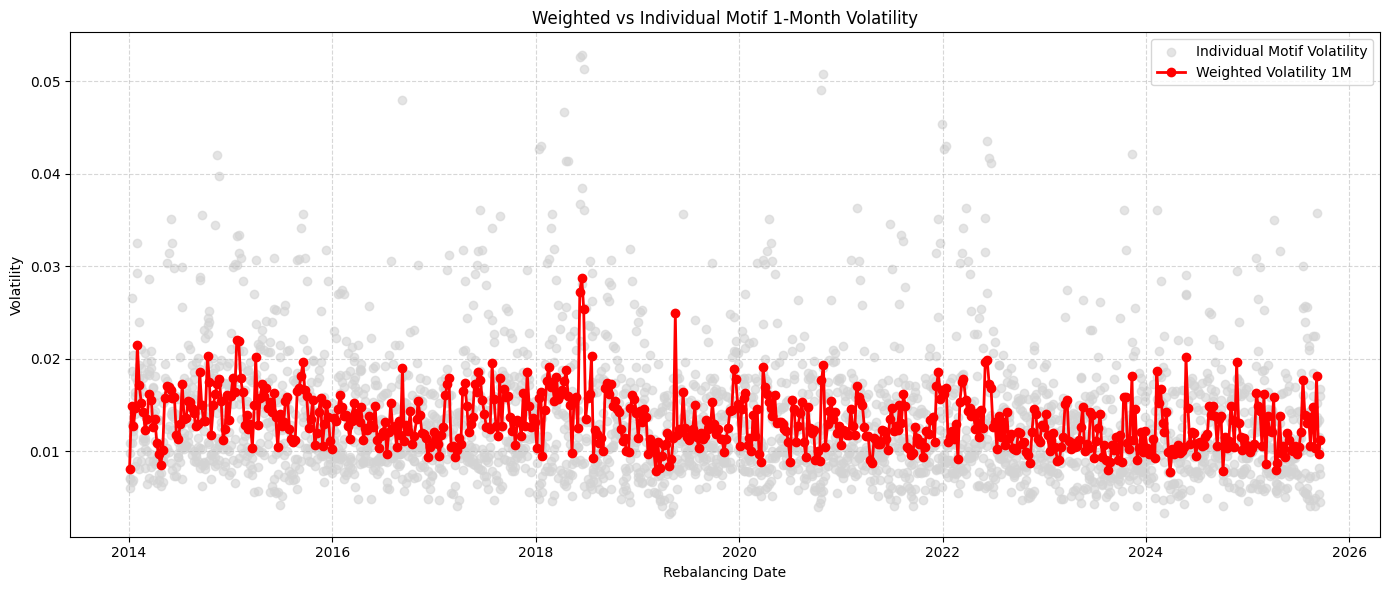

In [10]:
import matplotlib.pyplot as plt

# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14, 6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd

def robust_nw_forecast(df, value_col, distance_col="dp", eta_factor=0.2):
    """
    Compute Nadaraya-Watson forecast with automatically scaled bandwidth.

    Parameters:
    - df: DataFrame with value_col (target) and distance_col (dp)
    - value_col: column to forecast (e.g., Vol_1M)
    - distance_col: column representing distance (smaller = closer)
    - eta_factor: fraction of mean distance to use as bandwidth (eta = mean(dp) * eta_factor)

    Returns:
    - Weighted forecast (float)
    """
    df = df[[value_col, distance_col]].dropna()
    if df.empty:
        return np.nan

    # Automatic bandwidth scaling
    mean_dp = df[distance_col].mean()
    eta = mean_dp * eta_factor
    if eta <= 0:
        eta = 1e-5  # safeguard

    # Gaussian kernel weights
    weights = np.exp(-(df[distance_col] ** 2) / (2 * eta**2))
    weights /= weights.sum()

    # Weighted forecast
    forecast = np.sum(weights * df[value_col])
    return forecast

# --- Compute NW forecast per rebal date ---
nw_forecasts = []

for rebal, group in top_regimes_df.groupby("RebalDate"):
    forecast = robust_nw_forecast(group, value_col="Vol_1M", distance_col="dp", eta_factor=0.2)
    nw_forecasts.append({"RebalDate": rebal, "NW_Vol_1M": forecast})

nw_forecast_df = pd.DataFrame(nw_forecasts).sort_values("RebalDate")

print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M
0 2014-01-03   0.007507
1 2014-01-10   0.009128
2 2014-01-17   0.013465
3 2014-01-24   0.016075
4 2014-01-31   0.024761


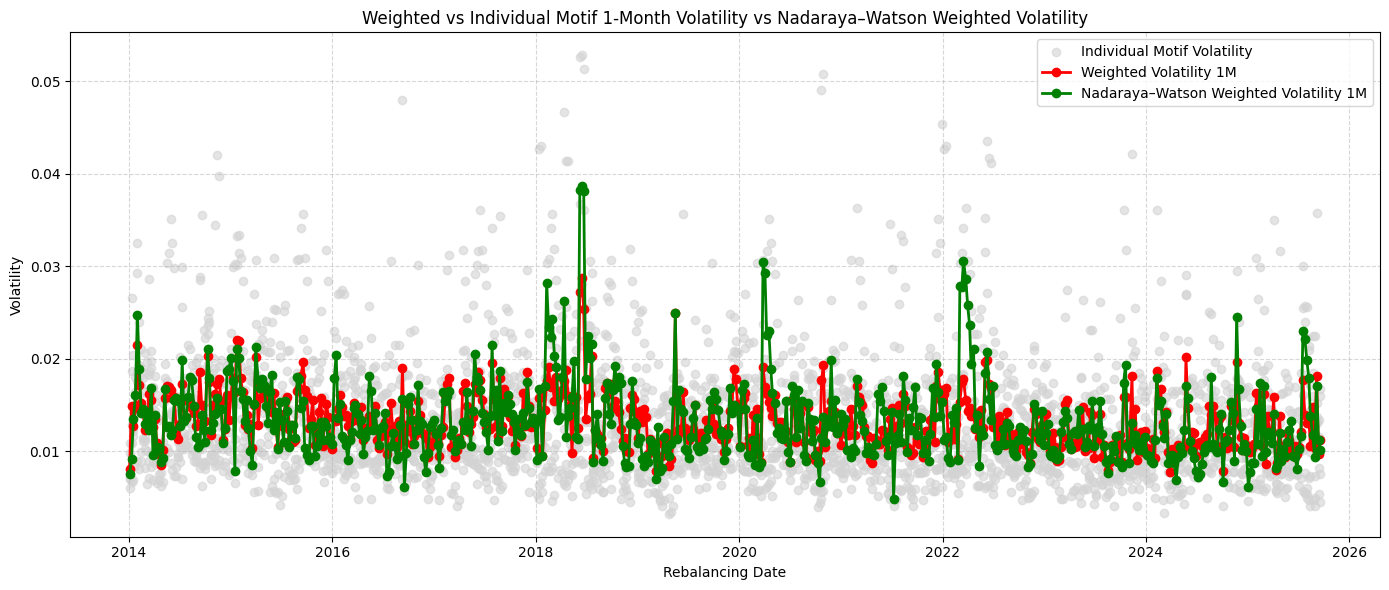

In [12]:
# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14,6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.plot(
    nw_forecast_df["RebalDate"],
    nw_forecast_df["NW_Vol_1M"],
    color='green',
    marker='o',
    linewidth=2,
    label="Nadaraya–Watson Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility vs Nadaraya–Watson Weighted Volatility")
plt.xlabel("Rebalancing Date")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# Function to compute realized 1-month volatility after a date
def realized_vol(df, date, window='1M', price_col=0):
    """
    df: price DataFrame (datetime index)
    date: reference date (datetime)
    window: pandas offset alias for 1 month ('1M')
    price_col: column index of prices
    """
    end_date = date + pd.DateOffset(months=1)
    mask = (df.index > date) & (df.index <= end_date)
    prices = df.loc[mask].iloc[:, price_col]
    if len(prices) < 2:
        return np.nan
    returns = prices.pct_change().dropna()
    return returns.std()  # daily volatility; multiply by sqrt(252) for annualized

# Ensure RebalDate column is datetime
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])

# Compute observed volatility per rebal date
observed_vols = []
for date in nw_forecast_df["RebalDate"]:
    obs_vol = realized_vol(closeMergedDf, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

nw_forecast_df["Observed_Vol_1M"] = observed_vols

# Inspect
print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M  Observed_Vol_1M
0 2014-01-03   0.007507         0.008733
1 2014-01-10   0.009128         0.007873
2 2014-01-17   0.013465         0.007741
3 2014-01-24   0.016075         0.006967
4 2014-01-31   0.024761         0.006032


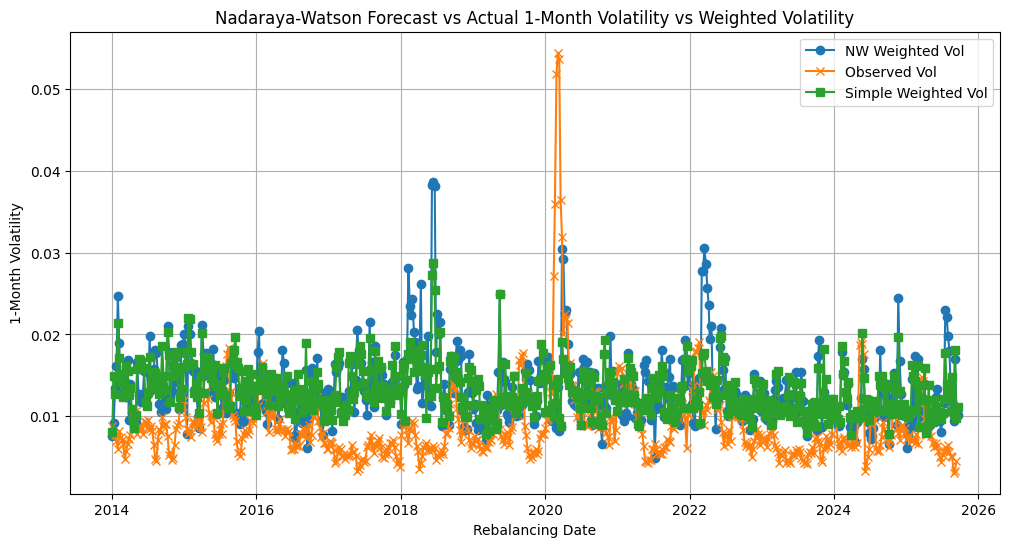

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["NW_Vol_1M"], marker='o', label="NW Weighted Vol")
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.plot(rebal_weighted_stats["RebalDate"],rebal_weighted_stats['WgtVol_1M'],marker='s', label="Simple Weighted Vol")

plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Nadaraya-Watson Forecast vs Actual 1-Month Volatility vs Weighted Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
correlation_nw = nw_forecast_df["NW_Vol_1M"].corr(nw_forecast_df["Observed_Vol_1M"])
correlation = rebal_weighted_stats['WgtVol_1M'].corr(nw_forecast_df["Observed_Vol_1M"])
print(f"Correlation between simple forecast and actual volatility: {correlation:.4f}")
print(f"Correlation between NW forecast and actual volatility: {correlation_nw:.4f}")

Correlation between simple forecast and actual volatility: 0.0052
Correlation between NW forecast and actual volatility: 0.0194


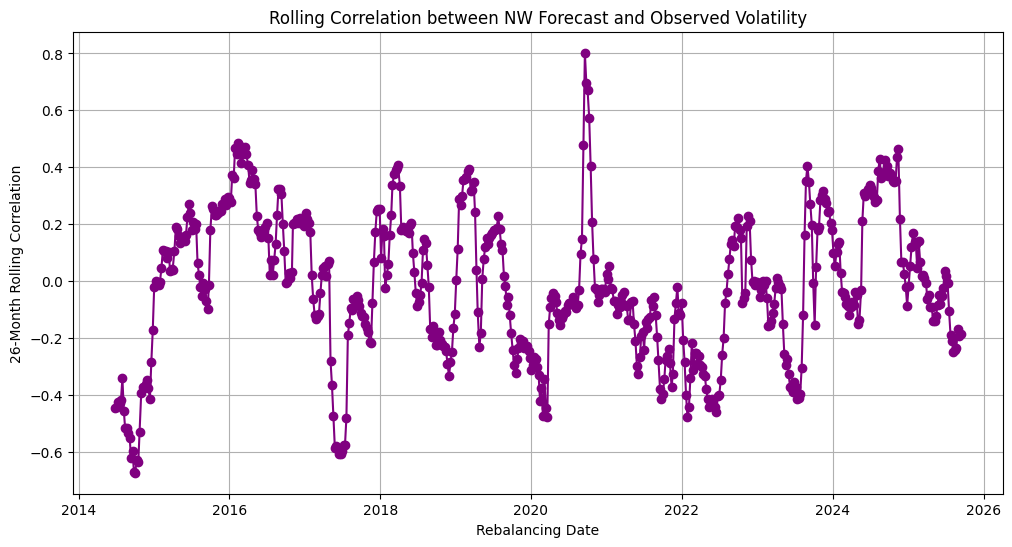

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure RebalDate is datetime and sorted
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
nw_forecast_df = nw_forecast_df.sort_values("RebalDate").reset_index(drop=True)

# Set rolling window (e.g., 3 or 6 months)
rolling_window = 26  # 3-month rolling correlation

# Compute rolling correlation
nw_forecast_df["RollingCorr"] = nw_forecast_df["NW_Vol_1M"].rolling(rolling_window).corr(
    nw_forecast_df["Observed_Vol_1M"]
)

# Plot rolling correlation
plt.figure(figsize=(12, 6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["RollingCorr"], marker='o', color='purple')
plt.xlabel("Rebalancing Date")
plt.ylabel(f"{rolling_window}-Month Rolling Correlation")
plt.title(f"Rolling Correlation between NW Forecast and Observed Volatility")
plt.grid(True)
plt.show()


In [17]:
# Get best matching motif (smallest dp) per rebal date
best_motif_df = top_regimes_df.loc[top_regimes_df.groupby("RebalDate")["dp"].idxmin()]

# Keep only relevant columns
best_motif_df = best_motif_df[["RebalDate", "Vol_1M", "dp"]].copy()
best_motif_df.rename(columns={"Vol_1M": "BestMotif_Vol_1M", "dp": "BestMotif_dp"}, inplace=True)
best_motif_df

,RebalDate,BestMotif_Vol_1M,BestMotif_dp
0,2014-01-03,0.006944,5.655035
5,2014-01-10,0.006681,5.655075
10,2014-01-17,0.020432,5.910643
15,2014-01-24,0.016367,5.563876
20,2014-01-31,0.029229,5.919610
...,...,...,...
3024,2025-08-22,0.004717,5.668088
3029,2025-08-29,0.007317,6.154454
3034,2025-09-05,0.015188,6.352878
3039,2025-09-12,0.013406,6.088180


In [18]:
# Merge on RebalDate
comparison_df = best_motif_df.merge(
    nw_forecast_df[["RebalDate", "Observed_Vol_1M"]],
    on="RebalDate",
    how="left"
)

# Inspect
print(comparison_df.head())


   RebalDate  BestMotif_Vol_1M  BestMotif_dp  Observed_Vol_1M
0 2014-01-03          0.006944      5.655035         0.008733
1 2014-01-10          0.006681      5.655075         0.007873
2 2014-01-17          0.020432      5.910643         0.007741
3 2014-01-24          0.016367      5.563876         0.006967
4 2014-01-31          0.029229      5.919610         0.006032


In [19]:
# Forecast error: best motif - observed
comparison_df["Error"] = comparison_df["BestMotif_Vol_1M"] - comparison_df["Observed_Vol_1M"]
comparison_df["AbsError"] = comparison_df["Error"].abs()

# Correlation
corr_best = comparison_df["BestMotif_Vol_1M"].corr(comparison_df["Observed_Vol_1M"])
print(f"Correlation between Best Motif Vol and Observed Vol: {corr_best:.4f}")


Correlation between Best Motif Vol and Observed Vol: 0.0310


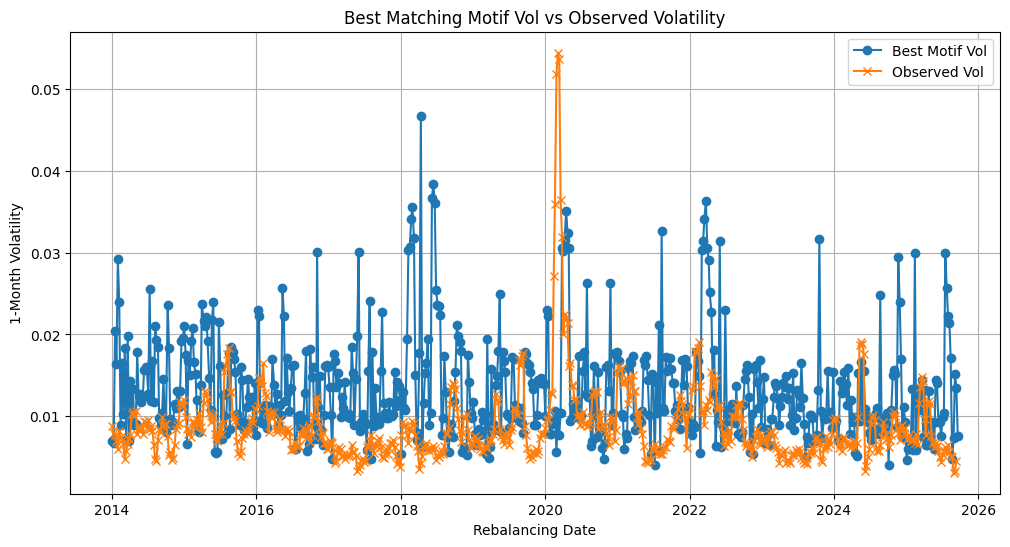

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_df["RebalDate"], comparison_df["BestMotif_Vol_1M"], marker='o', label="Best Motif Vol")
plt.plot(comparison_df["RebalDate"], comparison_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Best Matching Motif Vol vs Observed Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
rebal_weighted_stats

,RebalDate,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M
0,2014-01-03,0.008106,0.002592,0.001542,-0.221127,-0.168499
1,2014-01-10,0.014922,-0.001257,0.005750,-0.143497,-0.039957
2,2014-01-17,0.012729,-0.000427,0.003500,0.108131,-0.366705
3,2014-01-24,0.014631,0.000146,0.004275,-0.173027,0.353023
4,2014-01-31,0.021435,0.000766,0.009500,0.188114,1.178235
...,...,...,...,...,...,...
607,2025-08-22,0.014768,0.001556,0.004852,-0.044503,0.071672
608,2025-08-29,0.010314,0.003609,0.003023,-0.080281,-0.753362
609,2025-09-05,0.018138,-0.002143,0.008636,0.233823,-0.058230
610,2025-09-12,0.009720,0.000022,0.002118,0.093592,0.541630


In [24]:
price_df = closeMergedDf.copy()
price_df['return'] = price_df['.NSEI'].pct_change()
price_df = price_df.dropna()

In [25]:
# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = "2020-01-01"
end_date = price_df.index.max()  # last available date from your price data

weekly_rebal_dates = rebal_df.loc[(rebal_df['Date'] >= start_date) & (rebal_df['Date']<= end_date), 'Date'].tolist()

In [26]:
observed_vols_df = pd.DataFrame(index=weekly_rebal_dates)
observed_vols_df

""
2020-01-03
2020-01-10
2020-01-17
2020-01-24
2020-02-01
...
2025-08-22
2025-08-29
2025-09-05
2025-09-12


In [27]:
observed_vols = []
for date in weekly_rebal_dates:
    obs_vol = realized_vol(price_df, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

observed_vols_df["Observed_Vol_1M"] = observed_vols
observed_vols_df = observed_vols_df.dropna()

# Inspect
print(observed_vols_df.head())

            Observed_Vol_1M
2020-01-03         0.008523
2020-01-10         0.009498
2020-01-17         0.009656
2020-01-24         0.010789
2020-02-01         0.012903


In [29]:
hist_vol = observed_vols_df["Observed_Vol_1M"]

In [30]:
# --- Compute edges for 30 buckets ---
n_buckets = 30
hist_vol = observed_vols_df["Observed_Vol_1M"]

bucket_edges = np.quantile(hist_vol, np.linspace(0, 1, n_buckets+1))
print("Bucket edges:", bucket_edges)

# --- Update assign_bucket function (same as before) ---
def assign_bucket(vol, edges):
    """
    Map volatility to bucket 1..n_buckets based on edges
    """
    for i in range(len(edges)-1):
        if edges[i] <= vol < edges[i+1]:
            return i+1
    # Edge case: vol == max edge
    if vol >= edges[-1]:
        return len(edges)-1
    return np.nan

# --- Map predicted & weighted vols to buckets ---
nw_forecast_df["VolBucket"] = nw_forecast_df["NW_Vol_1M"].apply(lambda x: assign_bucket(x, bucket_edges))
rebal_weighted_stats["VolBucket"] = rebal_weighted_stats["WgtVol_1M"].apply(lambda x: assign_bucket(x, bucket_edges))
rebal_weighted_stats["Observed_VolBucket"] = rebal_weighted_stats["Observed_Vol_1M"].apply(lambda x: assign_bucket(x, bucket_edges))

# --- Compute mean per bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .mean()
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12,6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width/2, bucket_means["WgtVol_1M"], width=bar_width, label="Mean Predicted Vol", alpha=0.8)
plt.bar(x + bar_width/2, bucket_means["Observed_Vol_1M"], width=bar_width, label="Mean Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1-{n_buckets})")
plt.ylabel("Mean 1-Month Volatility")
plt.title(f"Mean Predicted vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional scatter with bucket labels
plt.figure(figsize=(8,8))
plt.scatter(bucket_means["Observed_Vol_1M"], bucket_means["WgtVol_1M"], color='royalblue', s=50)
lims = [
    min(bucket_means["Observed_Vol_1M"].min(), bucket_means["WgtVol_1M"].min()),
    max(bucket_means["Observed_Vol_1M"].max(), bucket_means["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')
plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Bucket edges: [0.00306995 0.00435851 0.00467356 0.0052055  0.00553277 0.00574528
 0.00598933 0.00619859 0.00629249 0.00650652 0.00665427 0.00690402
 0.00713423 0.00735006 0.00765977 0.00787707 0.00837464 0.00872956
 0.00898387 0.00951734 0.00972435 0.0099592  0.01043724 0.01116085
 0.01163348 0.01259968 0.01360519 0.01466759 0.01624204 0.02019817
 0.05448866]


KeyError: 'Observed_Vol_1M'

In [32]:
# Make sure Observed_Vol_1M is in rebal_weighted_stats
rebal_weighted_stats = rebal_weighted_stats.merge(
    nw_forecast_df[["RebalDate", "Observed_Vol_1M"]],
    on="RebalDate",
    how="left"
)


In [33]:
rebal_weighted_stats

,RebalDate,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,VolBucket,Observed_VolBucket,Observed_Vol_1M
0,2014-01-03,0.008106,0.002592,0.001542,-0.221127,-0.168499,NaN,NaN,0.008733
1,2014-01-10,0.014922,-0.001257,0.005750,-0.143497,-0.039957,NaN,NaN,0.007873
2,2014-01-17,0.012729,-0.000427,0.003500,0.108131,-0.366705,NaN,NaN,0.007741
3,2014-01-24,0.014631,0.000146,0.004275,-0.173027,0.353023,NaN,NaN,0.006967
4,2014-01-31,0.021435,0.000766,0.009500,0.188114,1.178235,NaN,NaN,0.006032
...,...,...,...,...,...,...,...,...,...
607,2025-08-22,0.014768,0.001556,0.004852,-0.044503,0.071672,NaN,NaN,0.004973
608,2025-08-29,0.010314,0.003609,0.003023,-0.080281,-0.753362,NaN,NaN,0.003070
609,2025-09-05,0.018138,-0.002143,0.008636,0.233823,-0.058230,NaN,NaN,0.003326
610,2025-09-12,0.009720,0.000022,0.002118,0.093592,0.541630,NaN,NaN,0.004494


In [34]:

n_buckets = 30

# Prepare columns for buckets
nw_forecast_df["VolBucket"] = np.nan
rebal_weighted_stats["VolBucket"] = np.nan
rebal_weighted_stats["Observed_VolBucket"] = np.nan

# Loop over each rebal date
for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        # Skip or assign NaN if not enough data
        continue

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Assign current predicted/weighted vol to bucket
    wgt_vol = rebal_weighted_stats.at[idx, "WgtVol_1M"]
    obs_vol = rebal_weighted_stats.at[idx, "Observed_Vol_1M"]
    nw_vol = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "NW_Vol_1M"].values[0]


    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    rebal_weighted_stats.at[idx, "VolBucket"] = assign_bucket(wgt_vol, bucket_edges)
    rebal_weighted_stats.at[idx, "Observed_VolBucket"] = assign_bucket(obs_vol, bucket_edges)
    nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "VolBucket"] = assign_bucket(nw_vol, bucket_edges)

# Now each date's bucket assignment only depends on past data → no forward bias


In [35]:
rebal_weighted_stats

,RebalDate,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,VolBucket,Observed_VolBucket,Observed_Vol_1M
0,2014-01-03,0.008106,0.002592,0.001542,-0.221127,-0.168499,NaN,NaN,0.008733
1,2014-01-10,0.014922,-0.001257,0.005750,-0.143497,-0.039957,NaN,NaN,0.007873
2,2014-01-17,0.012729,-0.000427,0.003500,0.108131,-0.366705,NaN,NaN,0.007741
3,2014-01-24,0.014631,0.000146,0.004275,-0.173027,0.353023,NaN,NaN,0.006967
4,2014-01-31,0.021435,0.000766,0.009500,0.188114,1.178235,NaN,NaN,0.006032
...,...,...,...,...,...,...,...,...,...
607,2025-08-22,0.014768,0.001556,0.004852,-0.044503,0.071672,28.0,3.0,0.004973
608,2025-08-29,0.010314,0.003609,0.003023,-0.080281,-0.753362,22.0,1.0,0.003070
609,2025-09-05,0.018138,-0.002143,0.008636,0.233823,-0.058230,29.0,1.0,0.003326
610,2025-09-12,0.009720,0.000022,0.002118,0.093592,0.541630,20.0,2.0,0.004494
